In [32]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os

load_dotenv()

True

In [33]:
llm = ChatGroq(model='llama-3.1-8b-instant', api_key=os.getenv("GROQ_API_KEY"),temperature=0.9)

In [34]:
class JokeState(TypedDict):
    user_input: str
    jokes: str
    explain_joke: str

In [40]:
def generate_joke(state: JokeState) -> JokeState:
    user_input = state['user_input']
    joke_response = llm.invoke(f"Tell me a joke about {user_input}")
    
    return {'jokes': joke_response.content}

def explain_joke(state: JokeState) -> JokeState:
    joke = state['jokes']
    explanation_response = llm.invoke(f"Explain the joke: {joke}")
    
    return {'explain_joke': explanation_response.content}

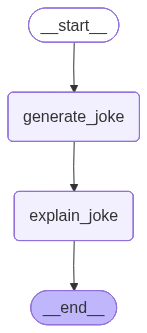

In [41]:
checkpointer = InMemorySaver()
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('explain_joke', explain_joke)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [48]:
thread_id = '1'
config = {'configurable': {'thread_id': thread_id}}
workflow.invoke({'user_input': 'dairy'}, config=config)

{'user_input': 'dairy',
 'jokes': 'Why did the cheese go to the party?\n\nBecause it wanted to have a gouda time.',
 'explain_joke': "The joke is a play on words. 'Gouda' is a type of cheese, and 'good' means pleasant or enjoyable. The punchline 'it wanted to have a gouda time' is a pun, substituting 'gouda' (the type of cheese) with 'good' (meaning having a good time) to create a humorous effect. So, the joke is saying that the cheese went to the party because it wanted to have a good time, but using the name of the cheese 'gouda' to make a cheesy pun."}

In [49]:
list(workflow.get_state(config))

# print(state.values["jokes"])
# print(state.values["explain_joke"])

[{'user_input': 'dairy',
  'jokes': 'Why did the cheese go to the party?\n\nBecause it wanted to have a gouda time.',
  'explain_joke': "The joke is a play on words. 'Gouda' is a type of cheese, and 'good' means pleasant or enjoyable. The punchline 'it wanted to have a gouda time' is a pun, substituting 'gouda' (the type of cheese) with 'good' (meaning having a good time) to create a humorous effect. So, the joke is saying that the cheese went to the party because it wanted to have a good time, but using the name of the cheese 'gouda' to make a cheesy pun."},
 (),
 {'configurable': {'thread_id': '1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f167f8a-f8fc-64f8-800a-cede9d61a40c'}},
 {'source': 'loop', 'step': 10, 'parents': {}},
 '2026-06-14T13:55:22.018100+00:00',
 {'configurable': {'thread_id': '1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f167f8a-f2b3-6466-8009-6ce18b83190b'}},
 (),
 ()]